In [32]:
import os
import xarray as xr
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

In [71]:
dir="/home/air673/torri_koastore/air_directory/Projects/DCI-Project/Model/cm1r20.3/run/MODEL_OUTPUT/Simulation_Two"
Nt=222
dt=180

In [72]:
# dir="/home/air673/torri_koastore/air_directory/Projects/DCI-Project/Model/cm1r20.3/run/MODEL_OUTPUT/Simulation_Three"
# Nt=661
# dt=60

In [73]:
import numpy as np

def CalculateThetaE(Theta, Qv, P, P0=1e5):
    # constants
    Rd = 287.0      # J/kg/K
    Cp = 1004.0     # J/kg/K
    Lv = 2.5e6      # J/kg

    # recover temperature
    Temperature = Theta * (P / P0) ** (Rd / Cp)

    # compute theta_e
    ThetaE = Theta * np.exp((Lv * Qv) / (Cp * Temperature))

    return ThetaE

In [74]:
#qv
qv_lst=[]
for t in tqdm(range(1, Nt)):
    fileName = f"cm1out_000{t:03d}.nc" 
    filePath = os.path.join(dir,fileName)
    data = xr.open_dataset(filePath,decode_timedelta=False)
    qv = data['qv'].isel(time=0,zh=0)
    qv_mean = np.mean(qv).item()
    qv_lst.append(qv_mean)

100%|██████████| 221/221 [00:11<00:00, 18.96it/s]


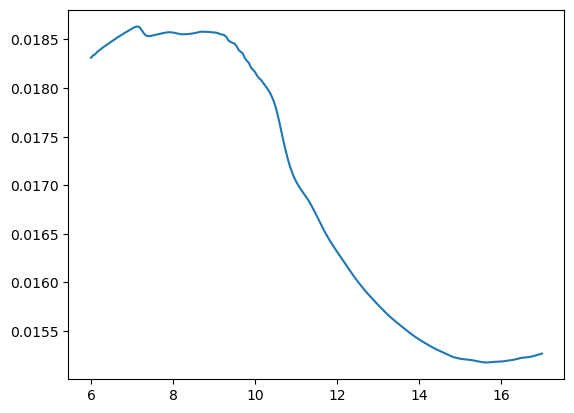

In [75]:
# qv
time = np.arange(Nt-1)*dt/3600+6
plt.plot(time,qv_lst)

In [76]:
#th
qv_lst=[]
for t in tqdm(range(1, Nt)):
    fileName = f"cm1out_000{t:03d}.nc" 
    filePath = os.path.join(dir,fileName)
    data = xr.open_dataset(filePath,decode_timedelta=False)
    qv = data['th'].isel(time=0,zh=0)
    qv_mean = np.mean(qv).item()
    qv_lst.append(qv_mean)

100%|██████████| 221/221 [00:11<00:00, 18.78it/s]


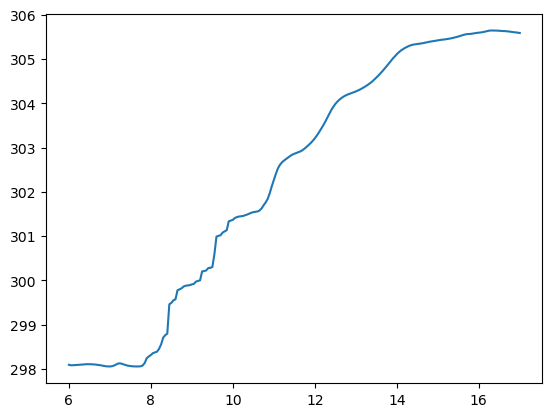

In [77]:
# th
time = np.arange(Nt-1)*dt/3600+6
plt.plot(time,qv_lst)

In [78]:
# th_e
qv_lst=[]
for t in tqdm(range(1, Nt)):
    fileName = f"cm1out_000{t:03d}.nc" 
    filePath = os.path.join(dir,fileName)
    data = xr.open_dataset(filePath,decode_timedelta=False)

    Theta = data['th'].isel(time=0,zh=0)
    Qv = data['qv'].isel(time=0,zh=0)
    P = data['prs'].isel(time=0,zh=0)

    qv = CalculateThetaE(Theta, Qv, P)
    qv_mean = np.mean(qv).item()
    qv_lst.append(qv_mean)

100%|██████████| 221/221 [00:13<00:00, 16.30it/s]


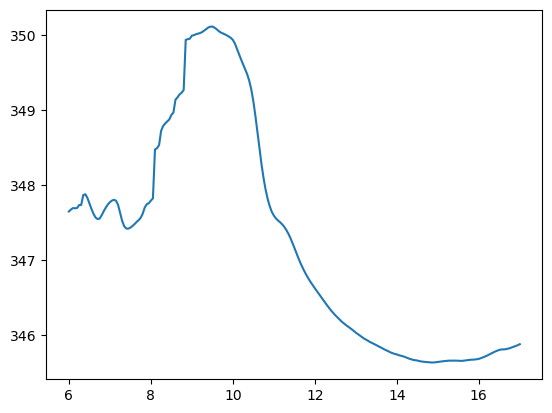

In [79]:
# th_e
time = np.arange(Nt-1)*dt/3600+6
plt.plot(time,qv_lst)

In [83]:
# qv= 0.0185; th=298 #8 am
# # qv= 0.0185; th = 301 #10 am

# qv= 0.0170; th = 302 #11 am


# ThetaE_quick = th * np.exp((2.5e6 * qv) / (1004.0 * th))
# ThetaE_quick

In [117]:

# for t in range(1,120,20): #0 to 6 hours in
#     fileName = f"cm1out_000{t:03d}.nc" 
#     filePath = os.path.join(dir,fileName)
#     data = xr.open_dataset(filePath,decode_timedelta=False)
#     qv = data['qv'].isel(time=0)
#     qv_mean=np.mean(qv,axis=1)
#     qv_mean[10:]=np.nan
#     levels=np.linspace(0.015,0.0175,20)

#     fig,axes=plt.subplots()
#     plt.contourf(data.xh,data.zh,qv_mean);plt.colorbar()
#     plt.ylim(0,0.5)
#     plt.title(f"{t*dt/3600+6} hrs")